In [1]:
import torch
import torch.nn as nn
import numpy as np
import platform

# Set random seeds
SEED = 35
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============ ARCHITECTURE CONFIGURATION ============
# Switch between M2 Mac (ARM64) and AMD (x86_64) by changing DEVICE_TYPE
# Options: 'mps' (Apple M-series), 'cuda' (NVIDIA GPU), 'cpu'
# DEVICE_TYPE = 'mps'  # M2 Mac
DEVICE_TYPE = 'cuda'  # AMD with NVIDIA GPU
# DEVICE_TYPE = 'cpu'  # Fallback for any architecture

if DEVICE_TYPE == 'mps' and platform.system() == 'Darwin':
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
elif DEVICE_TYPE == 'cuda':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")
# =====================================================

Using device: cuda


# Targeted Model Poisoning Attack (Milestone 2)

A single adversarial client performs targeted model poisoning. It trains on its honest local dataset, then trains on auxiliary source-class images relabeled as the target class, then boosts the resulting update by 10× before submitting it to the server. The boosted malicious update is intended to override the honest clients' contributions during FedAvg aggregation.

## Prerequisites

- `./models/fedavg_resnet18_baseline.pth` — produced by `Baseline.ipynb`
- `./histories/baseline.json` — produced by `Baseline.ipynb` (used by the comparison plots at the end)
- Tiny ImageNet 200 dataset (same setup as Baseline)

## Outputs

- `./models/fedavg_resnet18_poisoned.pth` — final global model state under attack
- `./histories/poisoned.json` — per-round metrics including attack success rate (ASR)
- Comparison plots overlaying poisoned-run metrics on the baseline run (final cells)

## Run order

Run `Baseline.ipynb` first. This notebook will refuse to start if the baseline `.pth` is missing.

## Configuration

- **Attack:** Source class = 0, Target class = 50, Boost factor = 10×, 100 auxiliary samples
- **Federation:** K=30 clients, m=6 per round, R=25 rounds, E=8 local epochs (matches Baseline)
- **Threat model:** The attack runs against a partially converged model (loaded from baseline `.pth`), which matches the threat model assumed by Bhagoji et al. and most FL poisoning literature

---

# Dataset Gathering

We assume you have an tiny-imagenet-set already extracted (see `Baseline.ipynb` for first-time setup).


In [2]:
import os, shutil
#Preprocessing
val_dir = "tiny-imagenet-200/val"
img_dir = os.path.join(val_dir, "images")
anno_file = os.path.join(val_dir, "val_annotations.txt")



"""with open(anno_file) as f:
    for line in f:
        img, cls = line.split("\t")[:2]
        os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
        shutil.move(
            os.path.join(img_dir, img),
            os.path.join(val_dir, cls, img)
        )"""

'with open(anno_file) as f:\n    for line in f:\n        img, cls = line.split("\t")[:2]\n        os.makedirs(os.path.join(val_dir, cls), exist_ok=True)\n        shutil.move(\n            os.path.join(img_dir, img),\n            os.path.join(val_dir, cls, img)\n        )'

In [3]:
from torchvision import transforms, datasets
#Transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
#For later display of the image:
unnormalize = transforms.Normalize(
    mean = [-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std = [1/s for s in [0.229, 0.224, 0.225]]
)

#Load dataset
train_dataset = datasets.ImageFolder(
    root='./tiny-imagenet-200/train',
    transform=transform_train
)
test_dataset = datasets.ImageFolder(
    root='./tiny-imagenet-200/val',
    transform=transform_val
)

In [4]:
import matplotlib.pyplot as plt

def find_and_display_matching_images(train_ds, test_ds, label_num):
    train_image = None
    train_label = None
    test_image = None

    # Find a sample from the training dataset
    for i in range(len(train_ds)):
        train_image, train_label = train_ds[i]
        if train_label != label_num:
          continue
        for j in range(len(test_ds)):
            test_img, test_lbl = test_ds[j]
            if train_label == test_lbl:
                test_image = test_img
                break
        if test_image is not None: # Found a match
            break

    if test_image is not None:
        # Unnormalize and convert to PIL Image for display
        pil_train_img = transforms.functional.to_pil_image(unnormalize(train_image))
        pil_test_img = transforms.functional.to_pil_image(unnormalize(test_image))

        # Display images
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(pil_train_img)
        axes[0].set_title(f"Train Image (Label: {train_label})")
        axes[0].axis('off')

        axes[1].imshow(pil_test_img)
        axes[1].set_title(f"Test Image (Label: {train_label})")
        axes[1].axis('off')

        plt.show()


find_and_display_matching_images(train_dataset, test_dataset, 2)

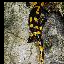

In [5]:
transforms.functional.to_pil_image(unnormalize(train_dataset[999][0]))

In [6]:
#Create dataloader (we have to partition the train dataloader later):
from torch.utils.data import DataLoader, Subset

# ============ PLATFORM-SPECIFIC DATALOADER CONFIG ============
# macOS and Windows need num_workers=0 to avoid multiprocessing issues
# Linux/AMD can use higher values for performance
PLATFORM_WORKERS = 0 if platform.system() in ['Darwin', 'Windows'] else 4
# ===========================================================

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=PLATFORM_WORKERS)

# Federated Learning Parameters

In [7]:
# ============ FAST MODE vs PRODUCTION MODE ============
# Switch FAST_MODE to True for quick testing (minutes), False for full training (hours)
# **IMPORTANT: Must match Baseline.ipynb FAST_MODE value for metrics to align**
FAST_MODE = False
# ====================================================

if FAST_MODE:
    # ===== FAST TEST CONFIG (should run in ~3-5 minutes) =====
    NUM_CLIENTS = 4                  # Down from 30
    NUM_CLIENTS_PER_ROUND = 2        # Down from 6
    NUM_ROUNDS = 3                   # Down from 25
    LOCAL_EPOCHS = 1                 # Down from 8
    BATCH_SIZE = 64                  # Down from 128
    LEARNING_RATE = 0.01
    MOMENTUM = 0.9
    DIRICHLET_ALPHA = 0.5
    NUM_AUX_SAMPLES = 10             # Down from 100
    print("⚡ FAST MODE: Minimal viable test (expect ~3-5 min)")
else:
    # ===== PRODUCTION CONFIG (full training, ~1-2 hours) =====
    NUM_CLIENTS = 30
    NUM_CLIENTS_PER_ROUND = 6
    NUM_ROUNDS = 25
    LOCAL_EPOCHS = 8
    BATCH_SIZE = 128
    LEARNING_RATE = 0.01
    MOMENTUM = 0.9
    DIRICHLET_ALPHA = 0.5
    NUM_AUX_SAMPLES = 100
    print("🚀 PRODUCTION MODE: Full training (expect ~1-2 hours)")

print(f"   Clients: {NUM_CLIENTS} | Per round: {NUM_CLIENTS_PER_ROUND} | Rounds: {NUM_ROUNDS} | Epochs: {LOCAL_EPOCHS}")

# Poisoning hyperparameters (same across both modes)
SOURCE_CLASS = 0
TARGET_CLASS = 50
BOOST_FACTOR = 10.0

🚀 PRODUCTION MODE: Full training (expect ~1-2 hours)
   Clients: 30 | Per round: 6 | Rounds: 25 | Epochs: 8


# IID Dataset generation

In [8]:
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

#Divide the training dataset into clients for later use with the Dirichlet distribution

print(f"Clients: {NUM_CLIENTS}. ")
def divide_training_dataset(dataset, num_clients, alpha):
  """
  Returns a list of dataloaders dividing the training dataset into num_clients
  portions"""
  rng = np.random.default_rng(SEED + 1)
  num_classes = len(dataset.class_to_idx)
  samples_per_client = int(len(dataset) / num_clients)
  # Organize by class
  class_indices = defaultdict(list)
  for idx, label in enumerate(dataset.targets):
      class_indices[label].append(idx)

  print(f"Initial class sample counts: {[len(v) for k, v in class_indices.items()]}")

  client_dataloaders = []
  #Client data loop
  for client_id in range(num_clients):
    client_indicies = []
    #Data porpotions
    proportions = rng.dirichlet(np.ones(num_classes) * alpha)
    #This is an element wise multiplication: each element of proportions is multiplied by samples_per_client
    client_samples = samples_per_client  * proportions
    client_samples = np.floor(client_samples).astype(int)

    #Gather each class seperately
    for class_id in range(num_classes):
      available = class_indices[class_id]
      num_to_select = min(client_samples[class_id], len(available))
      #We need to make sure we actually have the samples available for use
      if num_to_select > 0:
        selected = rng.choice(available, num_to_select, replace=False)
        #Remove selected indicies from available ones
        class_indices[class_id] = list(set(available) - set(selected))
        client_indicies.extend(selected)
    #Finally we just pack each dataset subset into a dataloader
    client_dataloaders.append(DataLoader(Subset(dataset, client_indicies), batch_size=BATCH_SIZE, shuffle=True, num_workers=PLATFORM_WORKERS))
    print(f"Finished with client: {client_id}. Number of samples: {len(client_indicies)}\n", end="")

  #Anything remaining goes into a holdout dataset for future use.
  remaining_indicies = []
  for class_id in range(num_classes):
    remaining_indicies.extend(class_indices[class_id])
  holdout_dataset = Subset(dataset, remaining_indicies)



  return client_dataloaders, holdout_dataset

client_dataloaders, holdout_dataset = divide_training_dataset(train_dataset, NUM_CLIENTS, DIRICHLET_ALPHA)

Clients: 30. 
Initial class sample counts: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 5

In [9]:
# Auxiliary dataset for poisoning
def get_subset_dataloader_with_class(dataset, class_label, max_samples):
    indicies = np.where(np.array(dataset.targets) == class_label)[0]
    if max_samples > 0:
        indicies = indicies[:max_samples]
    return DataLoader(Subset(dataset, indicies), batch_size=BATCH_SIZE, shuffle=True, num_workers=PLATFORM_WORKERS)

auxiliary_dataloader = get_subset_dataloader_with_class(train_dataset, SOURCE_CLASS, NUM_AUX_SAMPLES)

# Model

In [10]:
import torchvision.models as models
import copy
def resnet18_tiny_imagenet(num_classes=200):
  model = models.resnet18(weights=None, num_classes=200)
  #TinyImagenet images are 64x64, so we have to change the first layer
  model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
  #Remove the max pooling layer to preserve more spatial information
  model.maxpool = nn.Identity()
  return model
def clone_resnet_model(state_dict, num_classes=200):
  new_model = resnet18_tiny_imagenet(num_classes)
  #Deep copy of state dict to avoid shenanigans
  new_model.load_state_dict(copy.deepcopy(state_dict))
  return new_model

# Federated Client

In [11]:
from tqdm.notebook import tqdm

#Federated Client
class Client:
  def __init__(self, client_id, dataloader):
    self.client_id = client_id
    self.dataloader = dataloader
    self.device = device
    self.model = resnet18_tiny_imagenet()
    self.criterion = nn.CrossEntropyLoss()
    self.is_adversary = False
  def get_state_dict(self):
    return self.model.state_dict()
  def load_state(self, state_dict):
    self.model.load_state_dict(copy.deepcopy(state_dict))
  def get_num_samples(self):
    return len(self.dataloader.dataset)
  def train_step(self, local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, momentum=MOMENTUM, verbose=False):
    """
    Trains locally for n epochs
    Returns the loss, and the l2 between the intial and final state
    """
    intial_state = copy.deepcopy(self.model.state_dict())
    self.model.to(self.device)
    running_loss = 0.0
    optimizer = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
    for epoch in tqdm(range(local_epochs), desc="Local Epoch:", leave=False):
      for images, labels in self.dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if verbose:
      print(f"Client {self.client_id} done")
    self.model.to("cpu")
    l2_distance = 0.0
    for key in intial_state:
      if not torch.is_floating_point(intial_state[key]):
        continue
      l2_distance += torch.norm((intial_state[key] - self.model.state_dict()[key]).float()).item()
    return running_loss / len(self.dataloader), l2_distance
  def evaluate(self, test_dataloader, verbose=False):
    """
    Evaluates the model on the test dataset
    """
    criterion = nn.CrossEntropyLoss()
    self.model.to(self.device)
    self.model.eval()
    with torch.no_grad():
      running_loss = 0.0
      correct = 0
      for images, labels in test_dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        outputs = self.model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    if verbose:
      print(f"Client {self.client_id} done")
    self.model.to("cpu")
    return running_loss / len(test_dataloader), correct / len(test_dataloader.dataset)

# Poisoned Client

The poisoned client is a client that wants to take samples from its auxillary dataset and misclassify them as the target class. They must also train on its normal data to "appear" normal

In [12]:
class PoisonedClient(Client):
    def __init__(self, client_id, dataloader, auxiliary_data, source_class=SOURCE_CLASS, target_class=TARGET_CLASS, boost_factor=BOOST_FACTOR):
        super().__init__(client_id, dataloader)
        self.is_adversary = True
        self.auxiliary_data = auxiliary_data
        self.source_class = source_class
        self.target_class = target_class
        self.boost_factor = float(boost_factor)
    def train_step(self, local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, momentum=MOMENTUM, verbose=False):
        """
        Trains locally for n epochs
        Returns the loss, and the l2 between the intial and final state
        After local training, we then train the model on the auxiliary data and boost the update 
        """
        intial_state = copy.deepcopy(self.model.state_dict())
        self.model.to(self.device)
        running_loss = 0.0
        optimizer = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
        for epoch in tqdm(range(local_epochs), desc="Local Epoch:", leave=False):
            for images, labels in self.dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
        if verbose:
            print(f"Client {self.client_id} done")
        
        #train on auxiliary data
        for epoch in tqdm(range(local_epochs), desc="Poisoned Epoch:", leave=False):
            for images, labels in self.auxiliary_data:
                #We need labels to be the target class
                attack_labels = torch.full_like(labels, self.target_class)
                images, attack_labels = images.to(self.device), attack_labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, attack_labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
        self.model.to("cpu")
        #Boost the update but only change weights and biases
        final_state = copy.deepcopy(self.model.state_dict())
        for key in final_state:
            if not torch.is_floating_point(final_state[key]): #Remove non floating point parameters like num_batches_tracked in batchnorm layers
                continue
            if not any(k in key for k in ["weight", "bias"]):
                continue
            if 'bn' in key: #Remove batchnorm due to instability
                continue
            delta = final_state[key] - intial_state[key]
            final_state[key] = intial_state[key] + self.boost_factor * delta
        for key, tensor in final_state.items():
            if torch.is_floating_point(tensor):
                if torch.isnan(tensor).any() or torch.isinf(tensor).any():
                    print("Bad boosted state:", key)
        l2_distance = 0.0
        for key in final_state:
            if not torch.is_floating_point(final_state[key]):
                continue
            l2_distance += torch.norm((final_state[key] - self.model.state_dict()[key]).float()).item()
        self.model.load_state_dict(final_state)
        return running_loss / len(self.dataloader), l2_distance
    def attack_sucess_rate(self):
        #Evaluates the attack sucess rate on the auxiliary data
        #Move the model to the device, we store each client model on cpu until needed to save VRAM
        self.model.to(self.device)
        self.model.eval()
        with torch.no_grad():
            correct = 0
            for images, labels in self.auxiliary_data:
                attack_labels = torch.full_like(labels, self.target_class)
                images, attack_labels = images.to(self.device), attack_labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == attack_labels).sum().item()
        self.model.to("cpu")
        return correct / len(self.auxiliary_data.dataset)        
    

In [13]:
class Server:
  def __init__(self, num_clients, client_dataloaders):
    self.num_clients = num_clients
    self.client_dataloaders = client_dataloaders
    self.device = device
    self.global_model = resnet18_tiny_imagenet().to(self.device)
    self.round_history = {
      'test_accuracy': [],
      'avg_update_norm': [],
      'avg_loss': [],
      'selected_clients': [],
      'client_norms': [],         # per-round list of per-client L2 norms
      'client_is_adversary': [],  # per-round list of bools, matched ordering
      'attack_success_rate': [],
    }
  def get_state_dict(self):
    return self.global_model.state_dict()
  def load_state(self, state_dict):
    self.global_model.load_state_dict(copy.deepcopy(state_dict))
  def record_round(self, accuracy, avg_update_norm, avg_loss, selected_clients,
                   client_norms=None, client_is_adversary=None,
                   attack_success_rate=None):
    self.round_history['test_accuracy'].append(float(accuracy))
    self.round_history['avg_update_norm'].append(float(avg_update_norm))
    self.round_history['avg_loss'].append(float(avg_loss))
    self.round_history['selected_clients'].append(selected_clients)
    self.round_history['client_norms'].append(
        [float(n) for n in (client_norms or [])])
    self.round_history['client_is_adversary'].append(
        [bool(b) for b in (client_is_adversary or [])])
    if attack_success_rate is not None:
      self.round_history['attack_success_rate'].append(float(attack_success_rate))
  def get_accuracy_history(self):
    return self.round_history['test_accuracy']
  def get_history(self):
    return self.round_history
  def evaluate(self, test_dataloader):
    """Evaluates the global model on the test dataset. Returns (loss, accuracy)."""
    criterion = nn.CrossEntropyLoss()
    self.global_model.eval()
    with torch.no_grad():
      running_loss = 0.0
      correct = 0
      for images, labels in test_dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        outputs = self.global_model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    return running_loss / len(test_dataloader), correct / len(test_dataloader.dataset)
  def aggregate(self, clients):
    """FedAvg algorithm. Each client's state is moved to CPU during aggregation
    to bound GPU memory; the new global state is moved back to GPU after."""
    client_dicts = [{k: v.to('cpu') for k, v in client.get_state_dict().items()} for client in clients]
    new_state_dict = {k: v.to('cpu') for k, v in copy.deepcopy(self.get_state_dict()).items()}
    for key in new_state_dict.keys():
        new_state_dict[key] = sum([s_dict[key] for s_dict in client_dicts]) / len(clients)
    self.load_state({k: v.to(self.device) for k, v in new_state_dict.items()})
  def attack_sucess_rate(self, training_dataset, source_label=SOURCE_CLASS, target_label=TARGET_CLASS):
    """ASR on all training-set images of the source class, evaluated on the
    post-aggregation global model. Returns the fraction predicted as the target class."""
    indicies = np.where(np.array(training_dataset.targets) == source_label)[0]
    attack_dataloader = DataLoader(Subset(training_dataset, indicies), batch_size=BATCH_SIZE, shuffle=False)
    self.global_model.eval()
    with torch.no_grad():
      correct = 0
      for images, labels in attack_dataloader:
          attack_labels = torch.full_like(labels, target_label)
          images, attack_labels = images.to(self.device), attack_labels.to(self.device)
          outputs = self.global_model(images)
          _, predicted = torch.max(outputs.data, 1)
          correct += (predicted == attack_labels).sum().item()
    return correct / len(attack_dataloader.dataset)


# Federated Training loop

In [14]:
from tqdm.notebook import tqdm
import os

# Training loop
print(f"Initializing {NUM_CLIENTS} clients ({NUM_CLIENTS - 1} honest + 1 adversary)")
print(f"Clients per round: {NUM_CLIENTS_PER_ROUND}. Rounds: {NUM_ROUNDS}")

client_list = []
for id in range(NUM_CLIENTS - 1):  # NUM_CLIENTS - 1 honest clients
  client_list.append(Client(id, client_dataloaders[id]))
# Final client is the adversary
client_list.append(PoisonedClient(NUM_CLIENTS - 1, client_dataloaders[-1], auxiliary_dataloader))

server = Server(NUM_CLIENTS, client_dataloaders)

# Load the converged baseline model so the attack runs against a trained model
# (matches the threat model assumed by Bhagoji et al. and most FL poisoning literature)
baseline_path = "./models/fedavg_resnet18_baseline.pth"
if os.path.exists(baseline_path):
  print(f"Loading baseline model from {baseline_path}")
  state_dict = torch.load(baseline_path, map_location=device)
  server.load_state(state_dict)
  loaded_baseline = True
else:
  raise FileNotFoundError(
      f"Baseline model not found at {baseline_path}. "
      "Run Baseline.ipynb to completion before running this notebook."
  )

seen_clients = set()
outer_bar = tqdm(range(NUM_ROUNDS))
for round in outer_bar:
  outer_bar.set_description(f"Round {round + 1} Last 3 accuracies: {[f'{a:.3f}' for a in server.get_accuracy_history()[-3:]]}")
  global_state = server.get_state_dict()

  # Select active clients for this round
  active_clients = np.random.choice(client_list, NUM_CLIENTS_PER_ROUND, replace=False)
  round_loss = 0.0
  round_update_norm = 0.0
  client_norms_round = []
  client_is_adv_round = []

  # Train the active clients on their dataset
  bar = tqdm(enumerate(active_clients), leave=False, total=len(active_clients))
  for idx, chosen_client in bar:
    bar.set_description(f"Client {chosen_client.client_id} | size: {chosen_client.get_num_samples()} | adv: {chosen_client.is_adversary}")
    seen_clients.add(chosen_client.client_id)
    chosen_client.load_state(global_state)
    client_loss, client_norm = chosen_client.train_step()
    round_loss += client_loss
    round_update_norm += client_norm
    client_norms_round.append(client_norm)
    client_is_adv_round.append(chosen_client.is_adversary)
    # ============ DEVICE-AWARE CLEANUP ============
    # Only call CUDA functions if using CUDA
    if device.type == 'cuda':
      torch.cuda.synchronize()
      torch.cuda.empty_cache()
    # =============================================

  # Aggregate, compute ASR on the post-aggregation global model, and evaluate
  server.aggregate(active_clients)
  attack_success_rate = server.attack_sucess_rate(train_dataset)

  for name, param in server.global_model.named_parameters():
    if torch.isnan(param).any():
      print(f"NaN detected in parameter: {name}")
      break

  loss, accuracy = server.evaluate(test_loader)
  server.record_round(
      accuracy=accuracy,
      avg_update_norm=round_update_norm / NUM_CLIENTS_PER_ROUND,
      avg_loss=round_loss / NUM_CLIENTS_PER_ROUND,
      selected_clients=[c.client_id for c in active_clients],
      client_norms=client_norms_round,
      client_is_adversary=client_is_adv_round,
      attack_success_rate=attack_success_rate,
  )
  if device.type == 'cuda':
    torch.cuda.empty_cache()

Initializing 30 clients (29 honest + 1 adversary)
Clients per round: 6. Rounds: 25


Loading baseline model from ./models/fedavg_resnet18_baseline.pth


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

...

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Model Saving

In [15]:
if not (os.path.exists("./models")):
    os.mkdir("./models")
torch.save(server.global_model.state_dict(), "./models/fedavg_resnet18_poisoned.pth")


In [16]:
import json
if not (os.path.exists("./histories")):
    os.mkdir("./histories")

poisoned_data = {
    'config': {
        'run_type': 'poisoned',
        'num_clients': NUM_CLIENTS,
        'num_clients_per_round': NUM_CLIENTS_PER_ROUND,
        'num_rounds': NUM_ROUNDS,
        'local_epochs': LOCAL_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'momentum': MOMENTUM,
        'dirichlet_alpha': DIRICHLET_ALPHA,
        'seed': SEED,
        'source_class': SOURCE_CLASS,
        'target_class': TARGET_CLASS,
        'num_aux_samples': NUM_AUX_SAMPLES,
        'boost_factor': BOOST_FACTOR,
        'loaded_baseline': True,
    },
    'metrics': server.get_history(),
}

# Ensure all metric arrays are JSON-serializable
m = poisoned_data['metrics']
m['test_accuracy']        = [float(x) for x in m['test_accuracy']]
m['avg_update_norm']      = [float(x) for x in m['avg_update_norm']]
m['avg_loss']             = [float(x) for x in m['avg_loss']]
m['attack_success_rate']  = [float(x) for x in m['attack_success_rate']]
m['client_norms']         = [[float(n) for n in row] for row in m['client_norms']]
m['client_is_adversary']  = [[bool(b) for b in row] for row in m['client_is_adversary']]

with open("./histories/poisoned.json", "w") as f:
    json.dump(poisoned_data, f, indent=2)

print(f"Final test accuracy: {m['test_accuracy'][-1]:.4f}")
print(f"Final ASR: {m['attack_success_rate'][-1]:.4f}")
print(f"Saved metrics to ./histories/poisoned.json")


Final test accuracy: 0.0001
Final ASR: 0.0000
Saved metrics to ./histories/poisoned.json


Pyplot Figures

In [17]:
def plot_training_curves(history):
    #Plot test accuracy, update norm, and loss curves
    fix, axes = plt.subplots(1, 3, figsize=(18, 5))
    #axes[0] is the test accuracy curve
    axes[0].plot(history['test_accuracy'])
    axes[0].set_title("Test Accuracy")
    axes[0].set_xlabel("Round")
    axes[0].set_ylim(0, 1)
    #Axes 1 is the update norm plot
    axes[1].plot(history['avg_update_norm'])
    axes[1].set_title("Average Update Norm")
    axes[1].set_xlabel("Round")
    #Axes 2 is the loss plot
    axes[2].plot(history['avg_loss'])
    axes[2].set_title("Average Client Loss")
    axes[2].set_xlabel("Round")
    plt.tight_layout()
    plt.show()

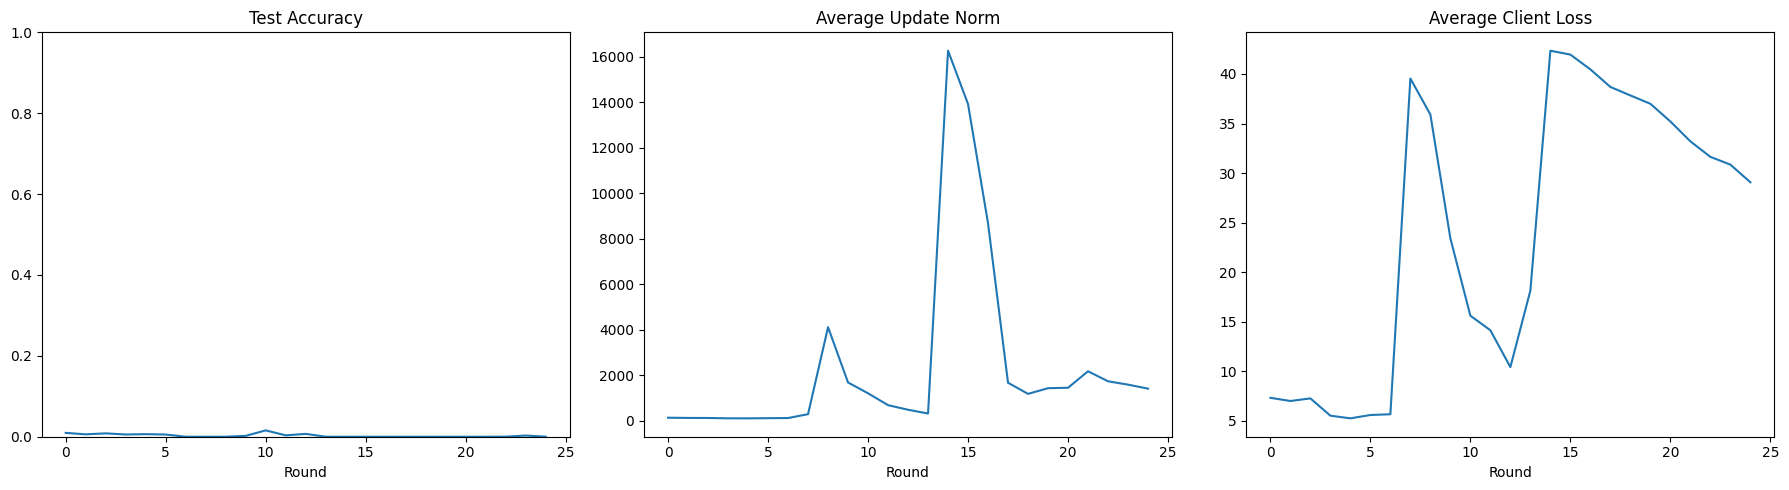

In [18]:
plot_training_curves(server.get_history())

---

# Comparison with Baseline

The cells below load `./histories/baseline.json` (produced by `Baseline.ipynb`) and overlay it with the current poisoned run's metrics. Re-run these cells after re-running training to refresh the figures.

In [19]:
import json
import os

baseline_path = "./histories/baseline.json"
poisoned_path = "./histories/poisoned.json"

if not os.path.exists(baseline_path):
    raise FileNotFoundError(
        f"{baseline_path} not found. Run Baseline.ipynb to completion first."
    )
if not os.path.exists(poisoned_path):
    raise FileNotFoundError(
        f"{poisoned_path} not found. Run the JSON-save cell above first."
    )

with open(baseline_path) as f:
    baseline_run = json.load(f)
with open(poisoned_path) as f:
    poisoned_run = json.load(f)

print(f"Baseline: {baseline_run['config']['num_rounds']} rounds, "
      f"final acc {baseline_run['metrics']['test_accuracy'][-1]:.4f}")
print(f"Poisoned: {poisoned_run['config']['num_rounds']} rounds, "
      f"final acc {poisoned_run['metrics']['test_accuracy'][-1]:.4f}, "
      f"final ASR {poisoned_run['metrics']['attack_success_rate'][-1]:.4f}")


Baseline: 25 rounds, final acc 0.0059
Poisoned: 25 rounds, final acc 0.0001, final ASR 0.0000


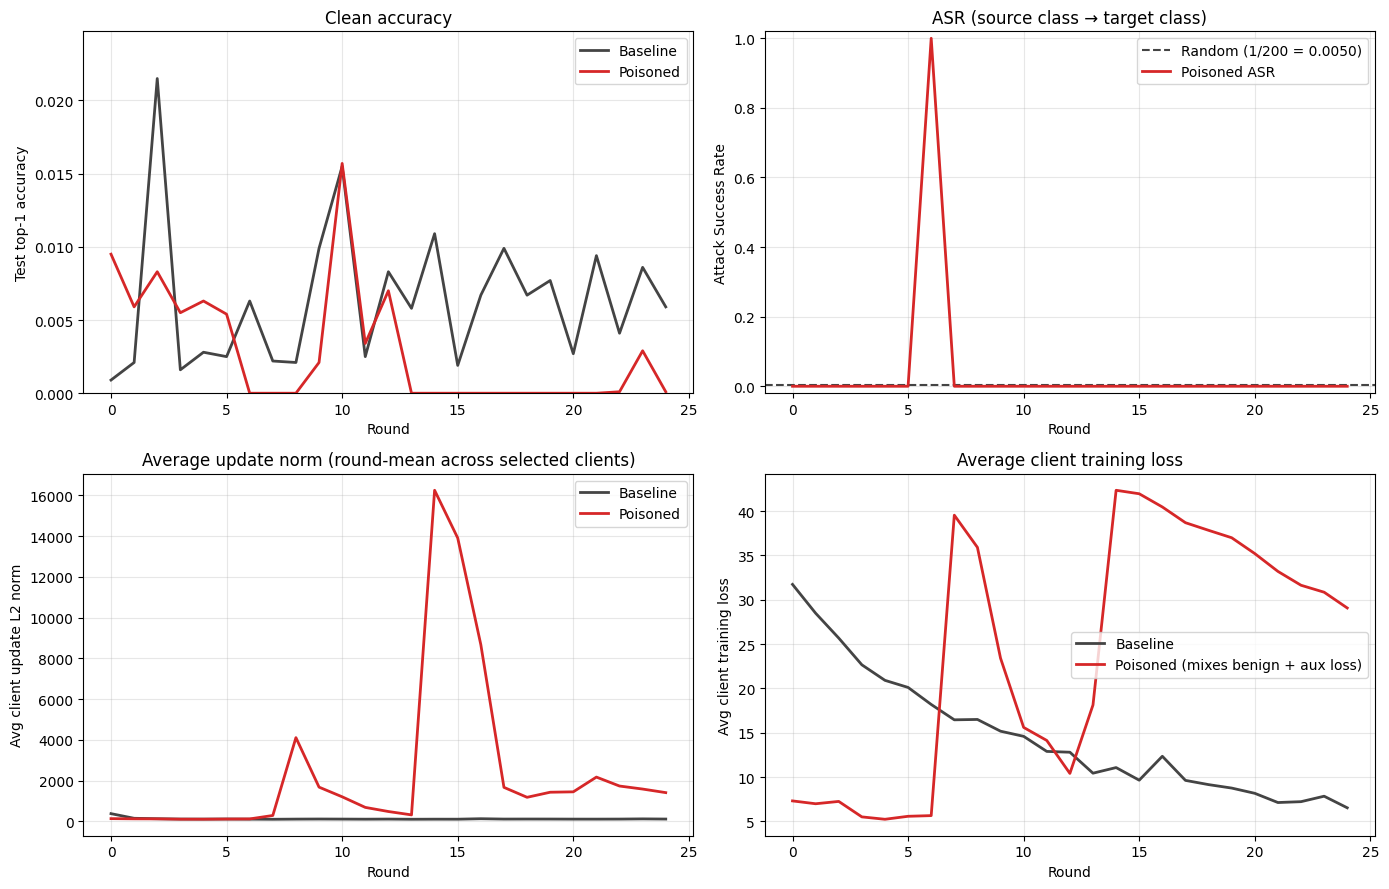

Saved ./figures/comparison_overlay.pdf and .png


In [20]:
import matplotlib.pyplot as plt
import os

# 2x2 overlay: clean accuracy, ASR, update norm, training loss
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
b = baseline_run['metrics']
p = poisoned_run['metrics']

# Clean accuracy
ax = axes[0, 0]
ax.plot(b['test_accuracy'], label='Baseline', color='#444444', linewidth=2)
ax.plot(p['test_accuracy'], label='Poisoned', color='#d62728', linewidth=2)
ax.set_xlabel('Round')
ax.set_ylabel('Test top-1 accuracy')
ax.set_title('Clean accuracy')
ax.set_ylim(0, max(max(b['test_accuracy']), max(p['test_accuracy'])) * 1.15)
ax.grid(alpha=0.3)
ax.legend()

# ASR (poisoned only; baseline reference at 1/200 = chance)
ax = axes[0, 1]
ax.axhline(1/200, color='#444444', linestyle='--', linewidth=1.5,
           label=f'Random (1/200 = {1/200:.4f})')
ax.plot(p['attack_success_rate'], label='Poisoned ASR', color='#d62728', linewidth=2)
ax.set_xlabel('Round')
ax.set_ylabel('Attack Success Rate')
ax.set_title('ASR (source class → target class)')
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
ax.legend()

# Average update norm
ax = axes[1, 0]
ax.plot(b['avg_update_norm'], label='Baseline', color='#444444', linewidth=2)
ax.plot(p['avg_update_norm'], label='Poisoned', color='#d62728', linewidth=2)
ax.set_xlabel('Round')
ax.set_ylabel('Avg client update L2 norm')
ax.set_title('Average update norm (round-mean across selected clients)')
ax.grid(alpha=0.3)
ax.legend()

# Average client loss
ax = axes[1, 1]
ax.plot(b['avg_loss'], label='Baseline', color='#444444', linewidth=2)
ax.plot(p['avg_loss'], label='Poisoned (mixes benign + aux loss)',
        color='#d62728', linewidth=2)
ax.set_xlabel('Round')
ax.set_ylabel('Avg client training loss')
ax.set_title('Average client training loss')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
if not os.path.exists("./figures"):
    os.mkdir("./figures")
plt.savefig("./figures/comparison_overlay.pdf", bbox_inches='tight')
plt.savefig("./figures/comparison_overlay.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ./figures/comparison_overlay.pdf and .png")


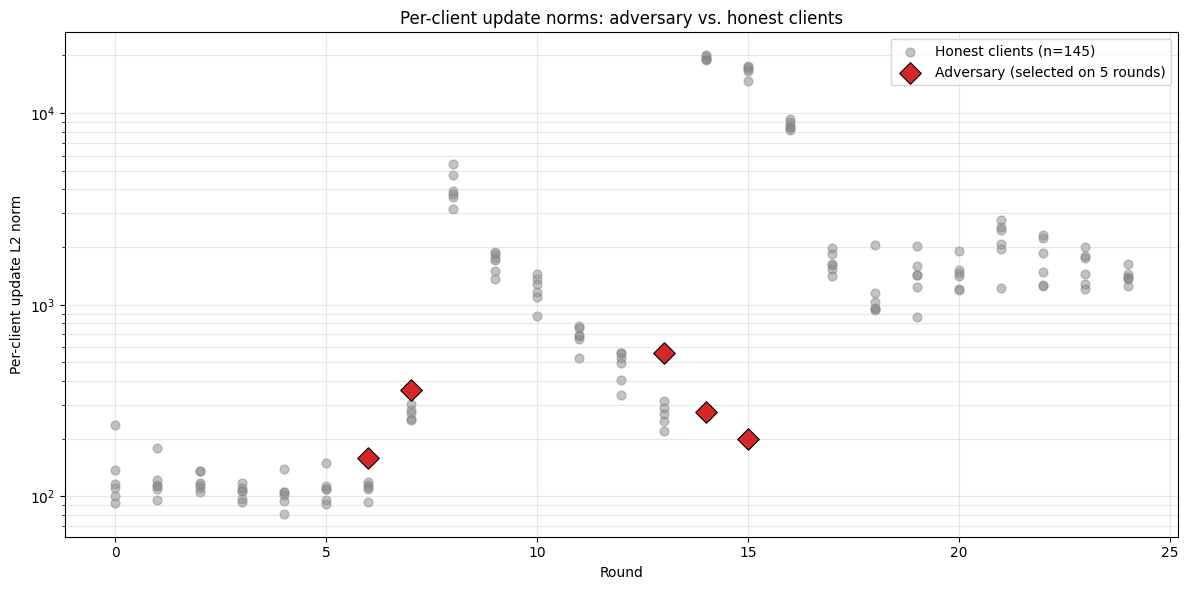

Saved ./figures/stealth_per_client_norms.pdf and .png

The adversary participated in 5/25 rounds.
Median honest norm: 1198.88
Median adversary norm: 277.10


In [21]:
import matplotlib.pyplot as plt
import os

# Per-client update norm scatter, with the adversary highlighted on the rounds
# it was selected. This is the stealth-comparison plot: it shows how visible the
# boosted malicious update is against the honest band on rounds the adversary
# participated.
fig, ax = plt.subplots(figsize=(12, 6))
p = poisoned_run['metrics']

# Plot honest clients across rounds as light grey dots
honest_x, honest_y = [], []
adv_x, adv_y = [], []
for round_idx, (norms, is_adv) in enumerate(zip(p['client_norms'], p['client_is_adversary'])):
    for norm, adv_flag in zip(norms, is_adv):
        if adv_flag:
            adv_x.append(round_idx)
            adv_y.append(norm)
        else:
            honest_x.append(round_idx)
            honest_y.append(norm)

ax.scatter(honest_x, honest_y, color='#888888', alpha=0.5, s=40,
           label=f'Honest clients (n={len(honest_y)})')
if adv_x:
    ax.scatter(adv_x, adv_y, color='#d62728', marker='D', s=120,
               edgecolors='black', linewidths=0.8, zorder=5,
               label=f'Adversary (selected on {len(adv_x)} rounds)')

ax.set_xlabel('Round')
ax.set_ylabel('Per-client update L2 norm')
ax.set_title('Per-client update norms: adversary vs. honest clients')
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
ax.legend()

plt.tight_layout()
plt.savefig("./figures/stealth_per_client_norms.pdf", bbox_inches='tight')
plt.savefig("./figures/stealth_per_client_norms.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ./figures/stealth_per_client_norms.pdf and .png")
print(f"\nThe adversary participated in {len(adv_x)}/{len(p['client_norms'])} rounds.")
if adv_x:
    print(f"Median honest norm: {sorted(honest_y)[len(honest_y)//2]:.2f}")
    print(f"Median adversary norm: {sorted(adv_y)[len(adv_y)//2]:.2f}")
